# Hierarchical calibration: a hierarchy on the physics parameters

Several experiments at different energies constrain a model whose parameters run
with energy.  We have to assume *something* about how they run — and if that
assumption is wrong, a global fit is confidently wrong everywhere, including at
energies nobody measured.

The repair is to stop insisting that one smooth curve describes every dataset,
and instead let each dataset have its own small deviation, with the *size* of
those deviations learned from the data.  That is a hierarchical model, and the
textbook version of it opens this notebook: the eight-schools problem from
[Gelman, Carlin, Stern, Dunson, Vehtari & Rubin, *Bayesian Data Analysis*, 3rd
edition](http://www.stat.columbia.edu/~gelman/book/) (BDA3), chapter 5.

Recipes: 22, 24, 30, 35, 38

In [1]:
import corner
import dynesty
import matplotlib.pyplot as plt
import numpy as np
import plotstyle
from scipy import stats

import rxmc as rx

plotstyle.use()

## Prologue: eight schools

Eight schools each ran a coaching programme, and each reported an estimated
effect $y_j$ on test scores together with the standard error $\sigma_j$ of that
estimate.  The estimates range from $+28$ to $-3$ points, but the standard
errors are 9 to 18 points, so the spread between schools is roughly what pure
noise would produce anyway.

Two extreme readings are available.  *No pooling* takes each school's estimate
at face value, which over-fits eight noisy numbers.  *Complete pooling* says the
programmes are identical and averages them, which throws away any real
difference.  The hierarchical model sits between: the true effects $\theta_j$
are drawn from a common distribution,

$$\theta_j \sim \mathcal{N}(\mu, \tau^2),$$

and we infer $\mu$, the spread $\tau$, and every $\theta_j$ at once.  How much a
school is pulled towards the common mean — *shrinkage* — follows from how big
$\tau$ turns out to be relative to that school's own error.

We write it non-centred, $\theta_j = \mu + \tau \eta_j$ with
$\eta_j \sim \mathcal{N}(0, 1)$, because sampling $\theta_j$ directly leaves a
funnel-shaped posterior that samplers struggle with.  In this spelling every
parameter has its own marginal prior, so nested sampling needs no joint
block.

In [2]:
Y = np.array([28.0, 8.0, -3.0, 7.0, -1.0, 1.0, 18.0, 12.0])
S = np.array([15.0, 10.0, 16.0, 11.0, 9.0, 11.0, 10.0, 18.0])
schools = rx.Dataset(np.arange(8), Y, S, label="schools")

mu = rx.Parameter("mu", prior=stats.norm(0.0, 25.0), latex=r"\mu")
tau = rx.Parameter(
    "tau", prior=stats.halfnorm(scale=10.0), bounds=(0.0, np.inf), latex=r"\tau"
)
etas = [
    rx.Parameter(f"eta_{j}", prior=stats.norm(0.0, 1.0), latex=rf"\eta_{j}")
    for j in range(8)
]
model = rx.Model(lambda x, mu, tau, *eta: mu + tau * np.asarray(eta), [mu, tau, *etas])
p_schools = rx.Problem([rx.Constraint([rx.Comparison(schools, model)])])
print("columns:", p_schools.names)

columns: ['mu', 'tau', 'eta_0', 'eta_1', 'eta_2', 'eta_3', 'eta_4', 'eta_5', 'eta_6', 'eta_7']


In [3]:
def nested(problem, seed, nlive=200, dlogz=0.5):
    sampler = dynesty.NestedSampler(
        problem.log_likelihood,
        problem.prior_transform,
        problem.ndim,
        nlive=nlive,
        sample="rwalk",
        rstate=np.random.default_rng(seed),
    )
    sampler.run_nested(dlogz=dlogz, print_progress=False)
    res = sampler.results
    print(
        f"log Z = {res.logz[-1]:8.2f} +/- {res.logzerr[-1]:.2f}, "
        f"{int(np.sum(res.ncall)):7d} likelihood calls"
    )
    return res.samples_equal(rstate=np.random.default_rng(seed))


s_schools = nested(p_schools, 0)
thetas = s_schools[:, [0]] + s_schools[:, [1]] * s_schools[:, 2:]

log Z =   -32.11 +/- 0.19,   14976 likelihood calls


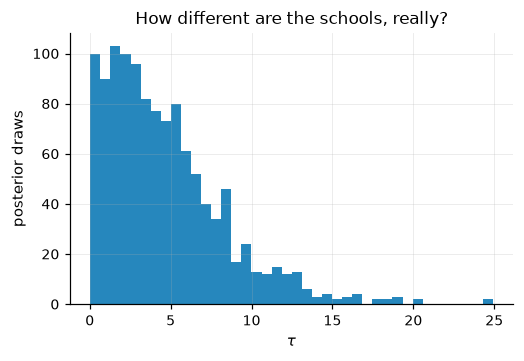

In [4]:
fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.hist(
    s_schools[:, p_schools.columns(tau)],
    bins=40,
    color=plotstyle.COLOURS[0],
    alpha=0.85,
)
ax.set(
    xlabel=r"$\tau$",
    ylabel="posterior draws",
    title=r"How different are the schools, really?",
)
plt.show()

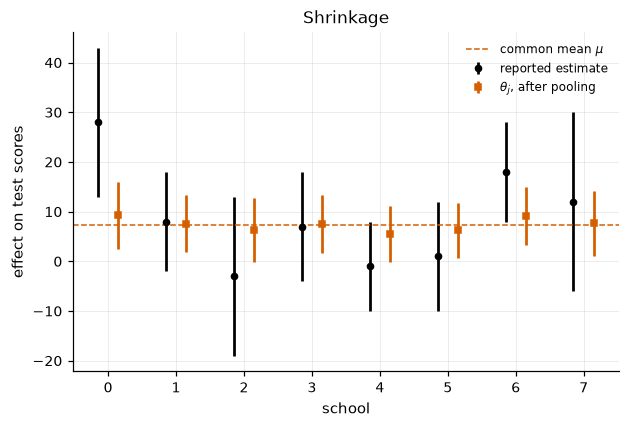

In [5]:
fig, ax = plt.subplots()
ax.errorbar(np.arange(8) - 0.15, Y, S, fmt="o", color="k", label="reported estimate")
ax.errorbar(
    np.arange(8) + 0.15,
    thetas.mean(0),
    thetas.std(0),
    fmt="s",
    color=plotstyle.COLOURS[1],
    label=r"$\theta_j$, after pooling",
)
ax.axhline(
    s_schools[:, 0].mean(),
    color=plotstyle.COLOURS[1],
    ls="--",
    lw=1.0,
    label=r"common mean $\mu$",
)
ax.set(xlabel="school", ylabel="effect on test scores", title="Shrinkage")
ax.legend(fontsize=8)
plt.show()

The posterior of $\tau$ piles up against zero, exactly as BDA3 reports.  The
data are consistent with all eight programmes having much the same effect, so
every school is pulled hard towards the common mean: school 1's $+28$ becomes
about $+10$, and the school reporting $-3$ moves up rather than down.  Nothing
was discarded — the shrinkage is what the model concludes, not a choice we
imposed.

Now the same idea, on physics parameters.

## The study: a quadratic whose coefficients run with energy

The truth is $y = a_0(E) + a_1(E)\, x + a_2(E)\, x^2$, and each coefficient's
energy dependence is a smooth trend plus a small non-monotonic bump — the kind of
structure a global parameterisation usually misses.  Seven synthetic datasets at
known energies constrain it, and an eighth at an energy between two of them is
held out to test prediction.

Every dataset reports an absolute error of 0.03 on each point, and those errors
are honest: the noise really is drawn from them.  So the only thing that can go
wrong here is the *model*, which is the point.

In [6]:
BUMPS = (0.16, -0.13, 0.1)  # amplitudes of the departures from each smooth trend


def a_true(E):
    return np.array(
        [
            1.0 + 0.010 * E + BUMPS[0] * np.exp(-(((E - 35.0) / 8.0) ** 2)),
            0.6 - 0.008 * E + BUMPS[1] * np.exp(-(((E - 25.0) / 6.0) ** 2)),
            -0.20 + 0.004 * E + BUMPS[2] * np.exp(-(((E - 45.0) / 7.0) ** 2)),
        ]
    )


def quadratic(x, a0, a1, a2):
    return a0 + a1 * x + a2 * x**2


rng = np.random.default_rng(12)
energies = np.array([10.0, 20.0, 25.0, 35.0, 40.0, 50.0, 60.0])
E_new = 30.0
x = np.linspace(-1.0, 1.0, 12)
noise = 0.03


def dataset(E, label):
    y = quadratic(x, *a_true(E))
    return rx.Dataset(
        x,
        y + rng.normal(0.0, noise, x.size),
        np.full(x.size, noise),
        label=label,
        meta={"Elab": E},
    )


datasets = [dataset(E, f"E = {E:.0f}") for E in energies]
held_out = dataset(E_new, f"E = {E_new:.0f} (held out)")

### The data, energy by energy

Seven datasets on the same $x$ grid would overlap into an unreadable smear, so we
offset each one vertically and label it.  The dashed lines are the truth at that
energy; the points are what the experiment saw.  The held-out energy is drawn in
grey.

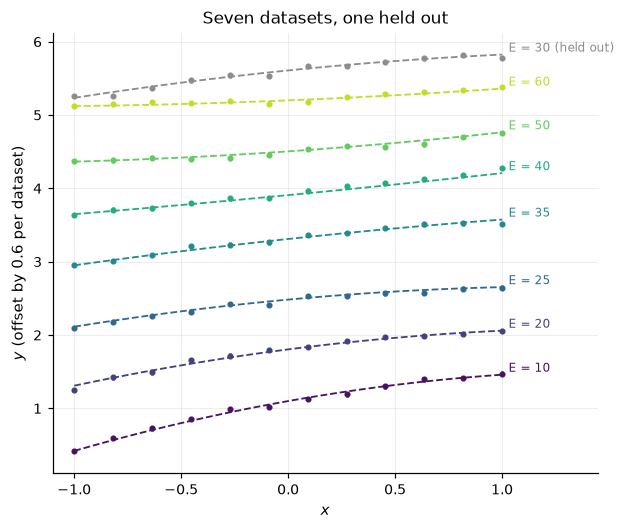

In [7]:
x_fine = np.linspace(-1.0, 1.0, 80)
offset_step = 0.6
shown = list(zip(datasets, energies)) + [(held_out, E_new)]
colours = plt.cm.viridis(np.linspace(0.05, 0.9, len(energies)))

fig, ax = plt.subplots(figsize=(6.4, 5.2))
for k, (d, E) in enumerate(shown):
    held = E == E_new
    colour = "0.55" if held else colours[k]
    shift = k * offset_step
    ax.plot(x_fine, quadratic(x_fine, *a_true(E)) + shift, "--", color=colour, lw=1.2)
    ax.errorbar(d.x, d.y + shift, d.y_err, fmt="o", ms=3, color=colour)
    plotstyle.label_at(
        ax,
        1.03,
        quadratic(1.0, *a_true(E)) + shift,
        f"E = {E:.0f}" + (" (held out)" if held else ""),
        color=colour,
    )
ax.set(
    xlabel="$x$",
    ylabel=f"$y$ (offset by {offset_step} per dataset)",
    title="Seven datasets, one held out",
    xlim=(-1.1, 1.45),
)
plt.show()

## Three fits of the same data

One `Model` per comparison, closing over that dataset's energy (recipe 35); the
coefficient objects are shared, so the problem has one column per global
parameter.  The held-out comparison is part of every constraint but fully
masked: it contributes nothing to the likelihood, and any parameter only it uses
is sampled from its prior (recipe 30).

1. **The correct mapping**,
   $a_k(E; \varphi) = \varphi_{k0} + \varphi_{k1} E + \varphi_{k2}
   \exp(-((E - c_k)/w_k)^2)$, with the bump centres and widths known: global
   $\varphi$.
2. **A misspecified smooth mapping**, $a_k(E; \varphi) = \varphi_{k0} +
   \varphi_{k1} E$: global $\varphi$, no bumps.
3. **The misspecified mapping plus a hierarchy**: per-dataset deviations
   $\delta_j = \tau \odot \eta_j$ in parameter space, non-centred, with
   $\eta_{jk} \sim \mathcal{N}(0, 1)$ and $\tau_k \sim \mathrm{HalfNormal}$, so
   the spread of the deviations is learned (recipes 22, 24).  The held-out
   dataset gets its own $\eta_\mathrm{new}$, driven by $\tau$ alone.

In [8]:
centres, widths = (35.0, 25.0, 45.0), (8.0, 6.0, 7.0)
all_data = datasets + [held_out]
masks = [np.ones(x.size, dtype=bool)] * len(datasets) + [np.zeros(x.size, dtype=bool)]


def correct_mapping(E, phi):
    phi = np.reshape(phi, (3, 3))
    return np.array(
        [
            phi[k, 0]
            + phi[k, 1] * E / 50.0
            + phi[k, 2] * np.exp(-(((E - centres[k]) / widths[k]) ** 2))
            for k in range(3)
        ]
    )


def linear_mapping(E, phi):
    phi = np.reshape(phi, (3, 2))
    return np.array([phi[k, 0] + phi[k, 1] * E / 50.0 for k in range(3)])

In [9]:
def global_params(prefix, n_per):
    return [
        [
            rx.Parameter(
                f"{prefix}{k}{i}",
                prior=stats.norm(0.0, 1.0),
                latex=rf"\varphi_{{{k}{i}}}",
            )
            for i in range(n_per)
        ]
        for k in range(3)
    ]


def build(mapping, phis, hierarchy=False):
    flat = [p for ps in phis for p in ps]
    taus = [
        rx.Parameter(
            f"tau_{k}",
            prior=stats.halfnorm(scale=0.2),
            bounds=(0.0, np.inf),
            latex=rf"\tau_{k}",
        )
        for k in range(3)
    ]
    comps = []
    for j, d in enumerate(all_data):
        E = d.meta["Elab"]
        if hierarchy:
            etas_j = [
                rx.Parameter(f"eta_{j}_{k}", prior=stats.norm(0.0, 1.0))
                for k in range(3)
            ]

            def fn(x, *v, E=E, n=len(flat)):
                phi, t, e = v[:n], np.asarray(v[n : n + 3]), np.asarray(v[n + 3 :])
                return quadratic(x, *(mapping(E, phi) + t * e))

            model_j = rx.Model(fn, [*flat, *taus, *etas_j])
        else:

            def fn(x, *phi, E=E):
                return quadratic(x, *mapping(E, phi))

            model_j = rx.Model(fn, flat)
        comps.append(rx.Comparison(d, model_j))
    c = rx.Constraint(comps, masks=masks)
    return rx.Problem([c]), c

In [10]:
cases = {
    "1. correct mapping": build(correct_mapping, global_params("phi", 3)),
    "2. misspecified": build(linear_mapping, global_params("psi", 2)),
    "3. misspecified + hierarchy": build(
        linear_mapping, global_params("chi", 2), hierarchy=True
    ),
}
for name, (p, c) in cases.items():
    print(
        f"{name:28s} ndim = {p.ndim:2d}   active points = {c.n_active} of {c.n_total}"
    )

1. correct mapping           ndim =  9   active points = 84 of 96
2. misspecified              ndim =  6   active points = 84 of 96
3. misspecified + hierarchy  ndim = 33   active points = 84 of 96


In [11]:
samples = {
    name: nested(p, seed=i + 1, nlive=100, dlogz=1.0)
    for i, (name, (p, c)) in enumerate(cases.items())
}

log Z =   143.07 +/- 1.16,  107467 likelihood calls
log Z =   -87.00 +/- 0.98,   69239 likelihood calls
log Z =   142.28 +/- 1.24,  257058 likelihood calls


## The coefficient mappings against the truth

For each case, the posterior band of $a_k(E)$ across the energy range.  The
hierarchical case has two things to show: the global smooth mapping, and the
per-dataset values $a_k(E_j) + \delta_{jk}$ it actually used, which are what
track the bumps.

In [12]:
mappings = {
    "1. correct mapping": correct_mapping,
    "2. misspecified": linear_mapping,
    "3. misspecified + hierarchy": linear_mapping,
}
style = {
    "1. correct mapping": (plotstyle.COLOURS[0], plotstyle.HATCHES[0]),
    "2. misspecified": (plotstyle.COLOURS[1], plotstyle.HATCHES[1]),
    "3. misspecified + hierarchy": (plotstyle.COLOURS[2], plotstyle.HATCHES[2]),
}
E_grid = np.linspace(5.0, 65.0, 100)
A_grid = np.array([a_true(E) for E in E_grid])
n_phi = {
    "1. correct mapping": 9,
    "2. misspecified": 6,
    "3. misspecified + hierarchy": 6,
}

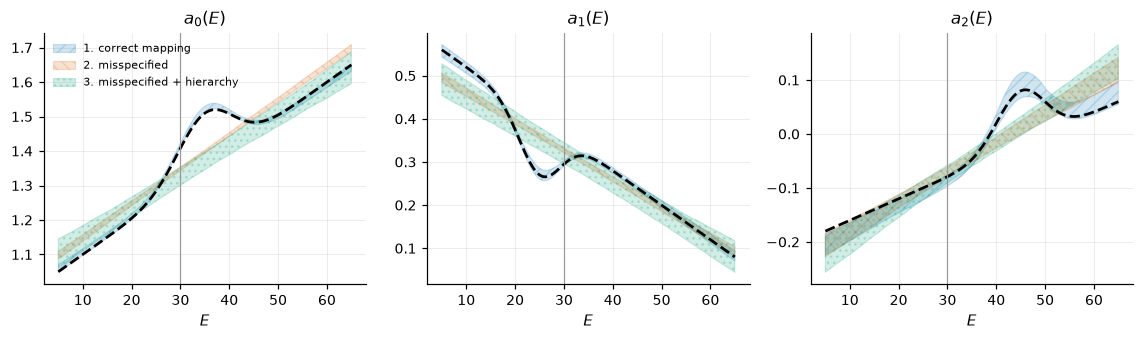

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2))
for name, (p, c) in cases.items():
    s = samples[name][::10]
    colour, hatch = style[name]
    curves = np.array(
        [[mappings[name](E, row[: n_phi[name]]) for E in E_grid] for row in s]
    )
    lo, hi = np.percentile(curves, [16, 84], axis=0)
    for k, ax in enumerate(axes):
        plotstyle.band(
            ax, E_grid, lo[:, k], hi[:, k], color=colour, hatch=hatch, label=name
        )
for k, ax in enumerate(axes):
    ax.plot(E_grid, A_grid[:, k], "--", color="k")
    ax.axvline(E_new, color="0.6", lw=0.8)
    ax.set(xlabel="$E$", title=f"$a_{k}(E)$")
axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

### What each case predicts, dataset by dataset

The same layout as the data figure — one offset row per energy — but now showing
what each calibration predicts.  The three cases are told apart by **hatching**
rather than colour, so the comparison survives a greyscale print and does not
fight the energy colour-coding.

In [14]:
def case_curves(name, E, rows):
    """y(x; E) over posterior rows, including this dataset's deviation.

    Pushed through by hand rather than with grid_draws: case 3 at the held-out
    energy needs a deviation eta for a dataset that has no column in the chain,
    and the reported point-by-point errors could not go on x_fine anyway.
    """
    p, _ = cases[name]
    n = n_phi[name]
    out = []
    for row in rows:
        coeffs = mappings[name](E, row[:n])
        if name.startswith("3"):
            j = list(energies).index(E) if E in energies else len(energies)
            tau_cols = p.columns([q for q in p.params if q.name.startswith("tau")])
            eta_cols = p.columns(
                [q for q in p.params if q.name.startswith(f"eta_{j}_")]
            )
            coeffs = coeffs + row[tau_cols] * row[eta_cols]
        out.append(quadratic(x_fine, *coeffs))
    return np.percentile(np.array(out), [16, 84], axis=0)

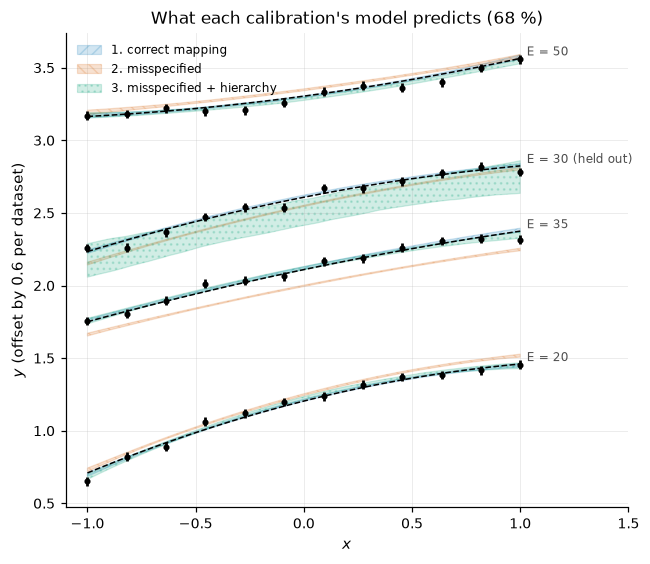

In [15]:
shown_energies = [20.0, 35.0, E_new, 50.0]
fig, ax = plt.subplots(figsize=(6.6, 5.6))
for k, E in enumerate(shown_energies):
    shift = k * offset_step
    d = held_out if E == E_new else datasets[list(energies).index(E)]
    for name in cases:
        colour, hatch = style[name]
        lo, hi = case_curves(name, E, samples[name][::20])
        plotstyle.band(
            ax,
            x_fine,
            lo + shift,
            hi + shift,
            color=colour,
            hatch=hatch,
            label=name if k == 0 else None,
        )
    ax.plot(x_fine, quadratic(x_fine, *a_true(E)) + shift, "--", color="k", lw=1.0)
    ax.errorbar(d.x, d.y + shift, d.y_err, fmt="o", ms=3, color="k")
    plotstyle.label_at(
        ax,
        1.03,
        quadratic(1.0, *a_true(E)) + shift,
        f"E = {E:.0f}" + (" (held out)" if E == E_new else ""),
        color="0.3",
    )
ax.set(
    xlabel="$x$",
    ylabel=f"$y$ (offset by {offset_step} per dataset)",
    title="What each calibration's model predicts (68 %)",
    xlim=(-1.1, 1.5),
)
ax.legend(fontsize=8, loc="upper left")
plt.show()

## Coverage, in sample and at the held-out energy

`predictive_draws` on the fitted problem gives the in-sample posterior
predictive; on `Problem([c.complement()])` — the same parameters and terms, with
the held-out points active — it gives the prediction at the new energy, with no
extra code (recipe 30).  For the hierarchical case that prediction includes the
prior-sampled $\eta_\mathrm{new}$ scaled by the learned $\tau$: a scale
mixture, wider and longer-tailed than in sample.

In [16]:
levels = np.linspace(0.1, 0.9, 9)
scores, curves_cov = {}, {}
for name, (p, c) in cases.items():
    s = samples[name]
    held = rx.Problem([c.complement()])
    draws_in = rx.diagnostics.predictive_draws(
        p, s[::10], n_rep=2, rng=1, return_draws=True
    )
    draws_out = rx.diagnostics.predictive_draws(
        held, s[::10], n_rep=2, rng=2, return_draws=True
    )
    ci, ch = p.constraints[0], held.constraints[0]
    curves_cov[name] = (
        rx.diagnostics.coverage_curve(draws_in, ci.y[ci.active], levels),
        rx.diagnostics.coverage_curve(draws_out, ch.y[ch.active], levels),
    )
    scores[name] = (
        rx.diagnostics.log_posterior_predictive(
            rx.diagnostics.heldout_log_predictive(held, s[::5])
        ),
        rx.diagnostics.sharpness(draws_out).mean(),
    )
print(f"{'case':28s} held-out log predictive   68 % predictive width")
for name, (lp, width) in scores.items():
    print(f"{name:28s} {lp:10.1f}                {width:.3f}")

case                         held-out log predictive   68 % predictive width
1. correct mapping                 24.7                0.062
2. misspecified                     7.7                0.061
3. misspecified + hierarchy        20.3                0.202


### What the three fits concluded

The evidence is the cleanest statement: $143.07$ for the correct mapping,
$-87.00$ for the misspecified one, and $142.28$ for the misspecified mapping
plus a hierarchy.  The first and third are a tie within their errors, and both
sit 230 log units above the second.  Giving each dataset a small deviation with
a learned spread recovers essentially all of the evidence that the wrong energy
dependence threw away — without our ever having to discover what the right
energy dependence was.

The held-out scores tell the same story with a caveat: $24.7$, $7.7$ and $20.3$.
The hierarchy recovers most, but not all, of the correct mapping's predictive
power at an energy it never saw, and it pays for that in width.  Its 68 %
predictive interval at the new energy is $0.202$ against $0.062$ — three times
wider.  That is the honest trade, not a defect: the hierarchy does not know
where the bump at $E = 30$ sits, so it predicts with the spread it learned,
which is wide enough to cover and no wider than it needs to be.

The coverage curves show it without the summary statistics.  The misspecified
fit sags well below the diagonal both in sample and at the held-out energy,
while the hierarchical fit tracks it.

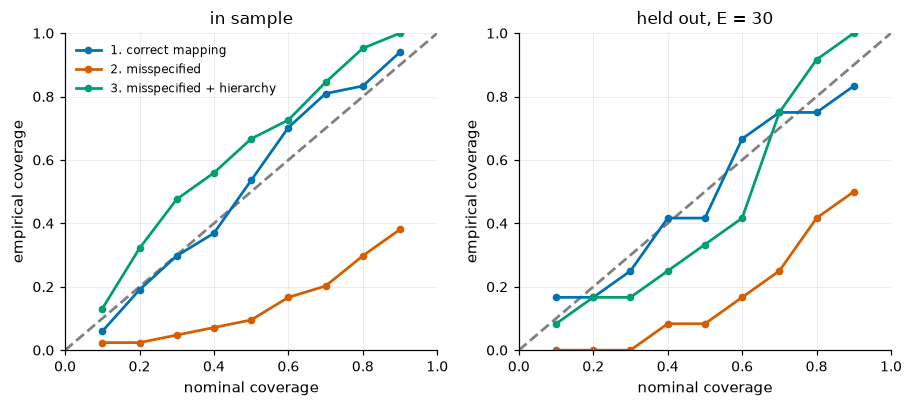

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.8))
for ax, which, title in zip(axes, (0, 1), ("in sample", f"held out, E = {E_new:.0f}")):
    ax.plot([0, 1], [0, 1], "--", color="0.5")
    for name in cases:
        ax.plot(levels, curves_cov[name][which], "o-", color=style[name][0], label=name)
    ax.set(
        xlabel="nominal coverage",
        ylabel="empirical coverage",
        title=title,
        xlim=(0, 1),
        ylim=(0, 1),
    )
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## The learned spread

The posterior of $\tau$ is what makes the misspecification visible: if the
smooth mapping were adequate, the data would have no reason to ask for
per-dataset deviations, and $\tau$ would collapse towards zero the way it did
for the eight schools.

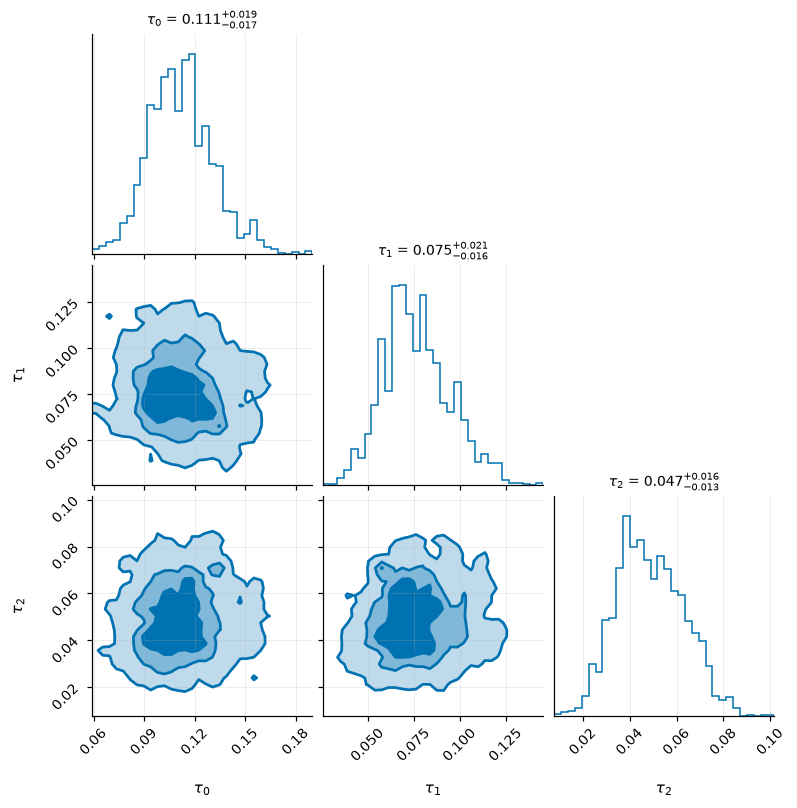

In [18]:
p3, _ = cases["3. misspecified + hierarchy"]
s3 = samples["3. misspecified + hierarchy"]
tau_params = [q for q in p3.params if q.name.startswith("tau")]
fig = corner.corner(
    s3[:, p3.columns(tau_params)],
    labels=[f"${q.latex}$" for q in tau_params],
    **plotstyle.corner_kwargs(title_fmt=".3f"),
)
plt.show()

## Takeaways

- The correct mapping covers in sample and out of sample.  The misspecified
  smooth mapping under-covers both, and leaves structured residuals at every
  energy.
- A hierarchy on the physics parameters recovers the coverage with wider,
  longer-tailed bands at the new energy, and a $\tau$ posterior away from zero
  is the misspecification made visible.
- A parameter attached only to a fully masked comparison is sampled from its
  prior.  That is the whole mechanism for predicting a new dataset:
  `complement()`, `predictive_draws` and `heldout_log_predictive` score the new
  energy with no extra code.
- With few datasets the global $\varphi$ and the deviations $\delta_j$ trade
  off against each other, and the hyperprior on $\tau$ is what resolves it.
  This is the same shrinkage the eight schools showed, now in parameter space.